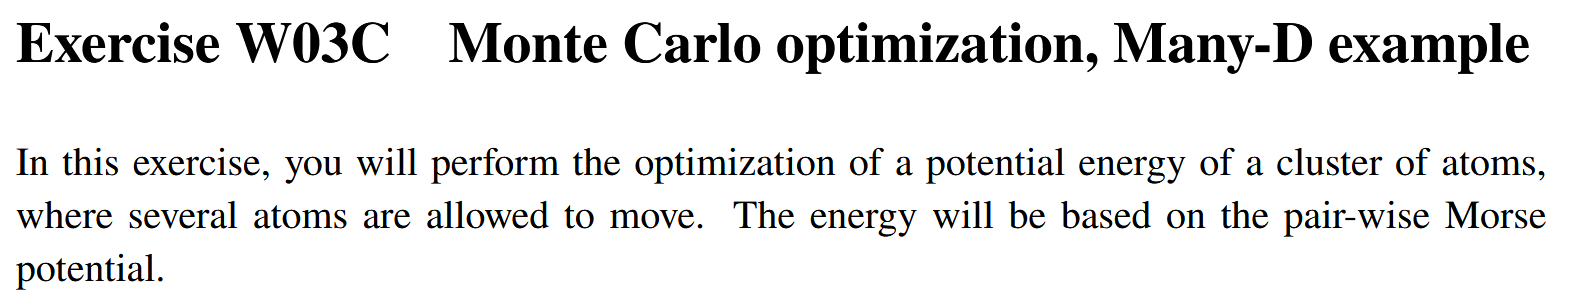
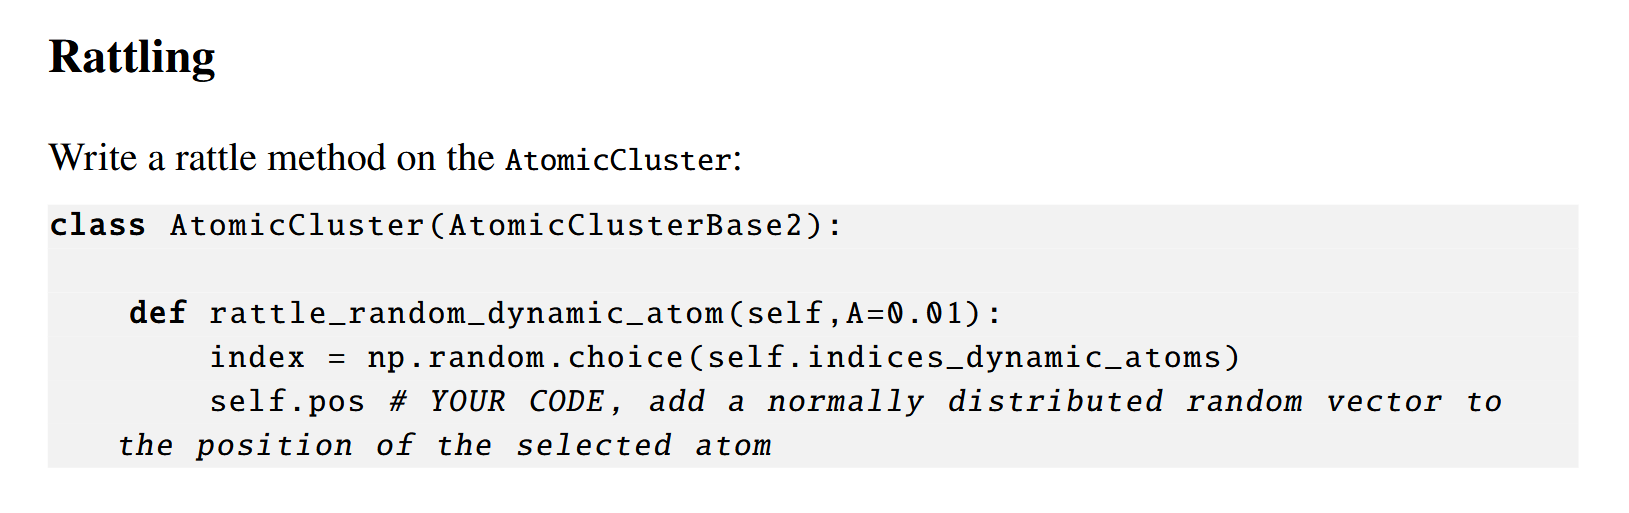

In [47]:
from week03 import *

class AtomicCluster(AtomicClusterBase2):

    def rattle_random_dynamic_atom(self, A=0.01):
        index = np.random.choice(self.indices_dynamic_atoms)
        self.pos[index] += np.random.normal(scale=A, size=2)



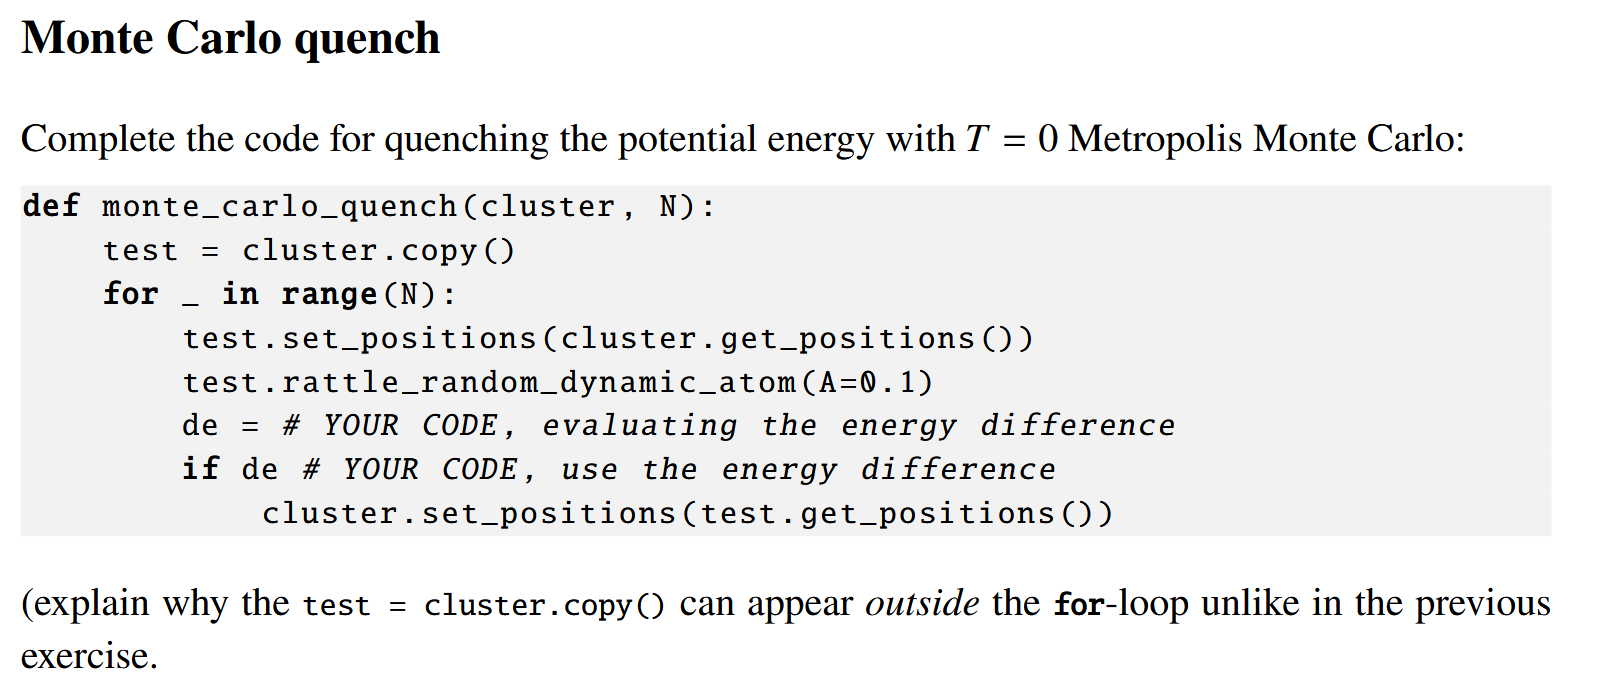
We can place it outside because we still return the position of the test if we dont accept.

In [48]:
def monte_carlo_quench(cluster, N):
    points = [cluster.get_positions()[0]]
    test = cluster.copy()
    for _ in range(N):
        test.set_positions(cluster.get_positions())
        test.rattle_random_dynamic_atom(A=1)
        de = test.potential_energy - cluster.potential_energy
        if de < 0:
            cluster.set_positions(test.get_positions())

        points.append(cluster.get_positions()[1])
    return np.array(points).transpose()


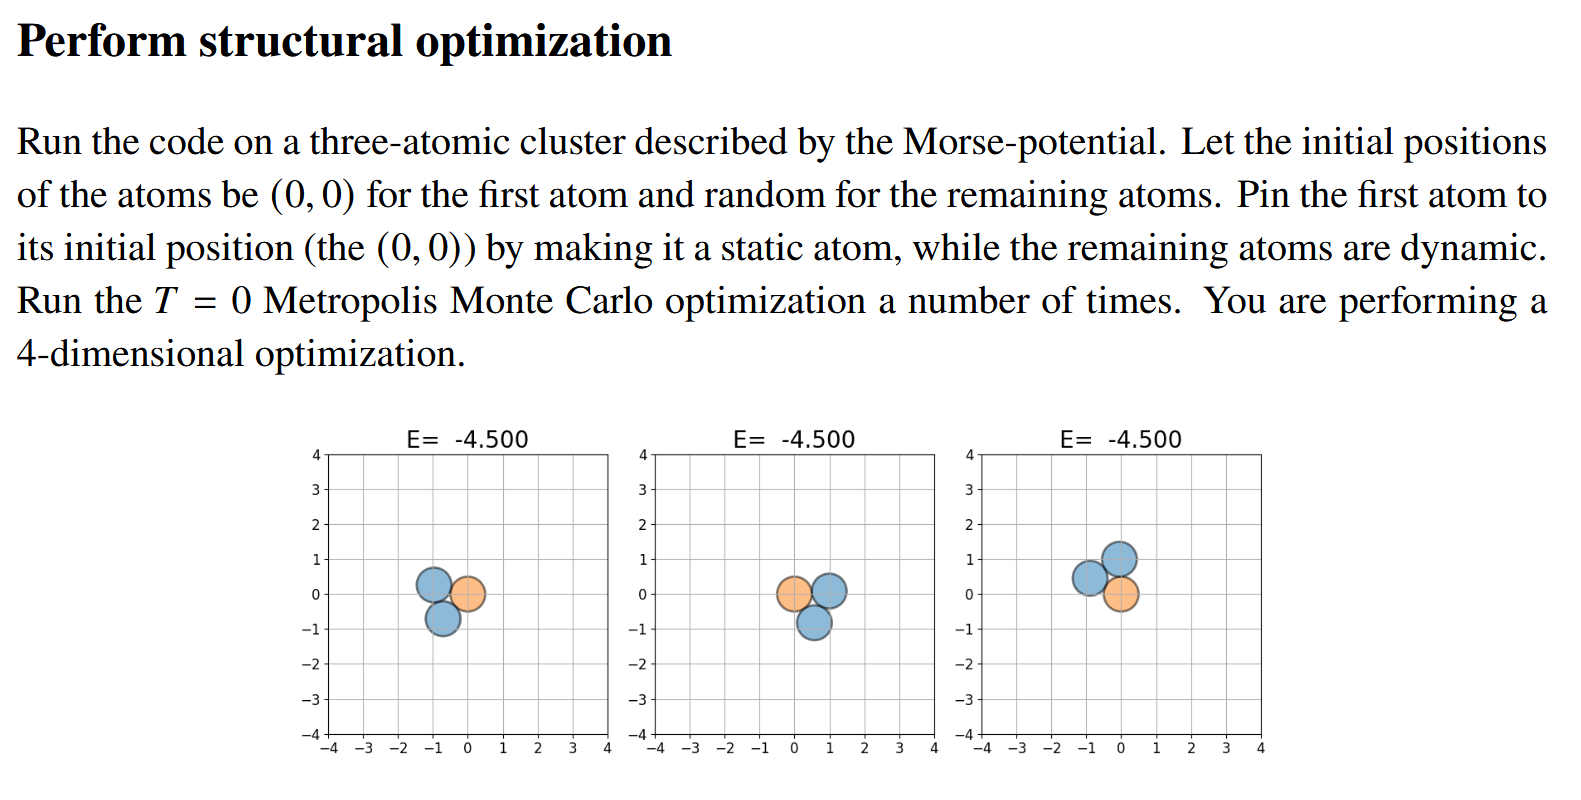

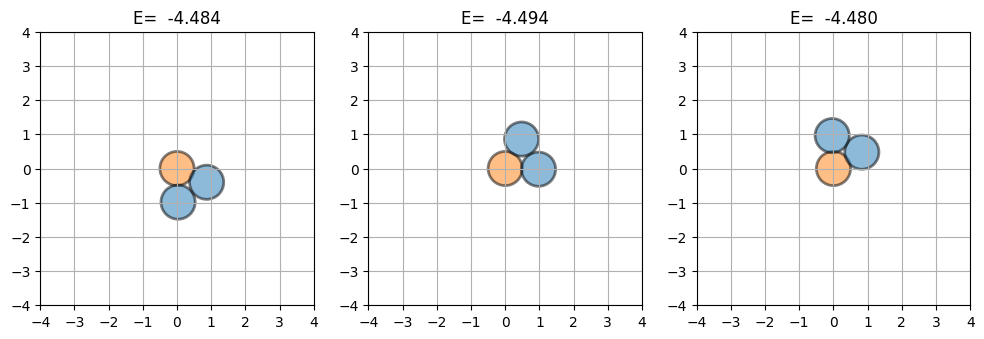

In [49]:
N = 3

fig, axes = plt.subplots(1, N, figsize=(4*N, 4))

morse = Morse()

for i in range(N):
    cluster = AtomicCluster(morse, N=N, static=[True]+[False]*(N-1))
    cluster.pos[0] = [0,0]
    monte_carlo_quench(cluster, 1000)
    cluster.draw(axes[i])
    nice_plot(axes[i], [-4, 4], [-4, 4])


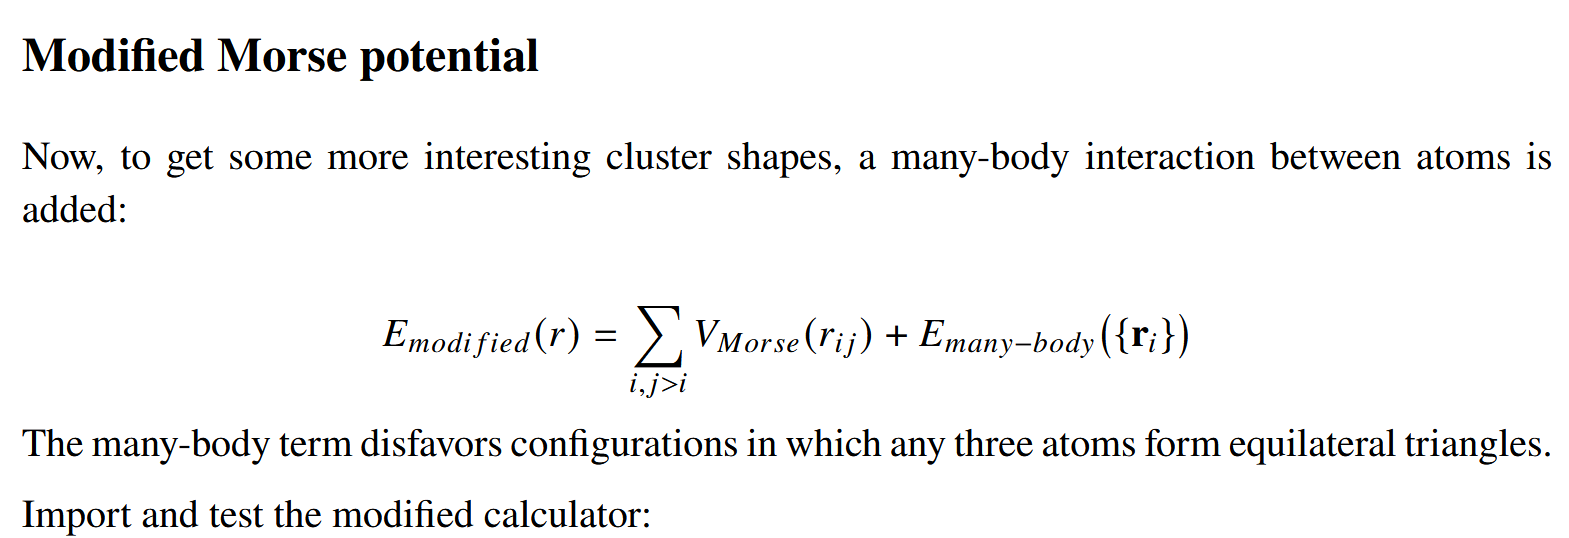
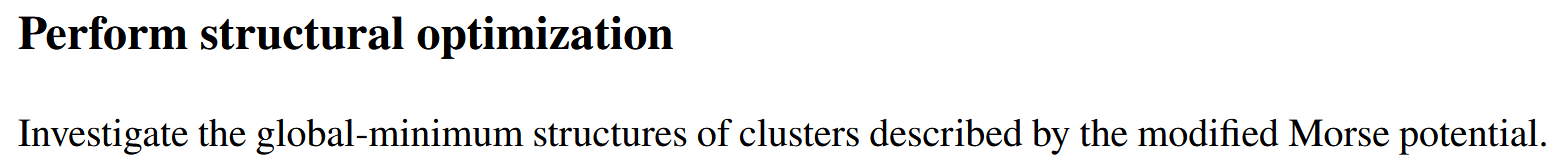

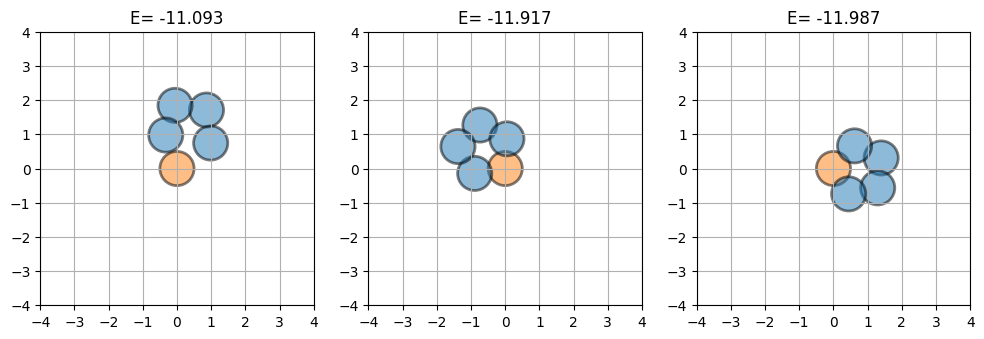

In [51]:
calc = ModifiedMorse()

N = 3

fig, axes = plt.subplots(1, N, figsize=(4*N, 4))

for i in range(N):
    n = 5
    cluster = AtomicCluster(calc, N=n, static=[True]+[False]*(n-1))
    cluster.pos[0] = [0,0]
    monte_carlo_quench(cluster, 10_000)
    cluster.draw(axes[i])
    nice_plot(axes[i], [-4, 4], [-4, 4])

The Ring structure has lowest potential, like a benzene ring